
Training 10 LR shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained
LR meta-classifier samples: 10,500

Training 10 GBT shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained
GBT meta-classifier samples: 10,500

Membership inference results:
                   Model  Train AUC  Test AUC  Generalization Gap  MI AUC
0    Logistic Regression      0.840     0.799               0.041   0.518
1  Gradient Boosted Tree      0.994     0.918               0.076   0.574


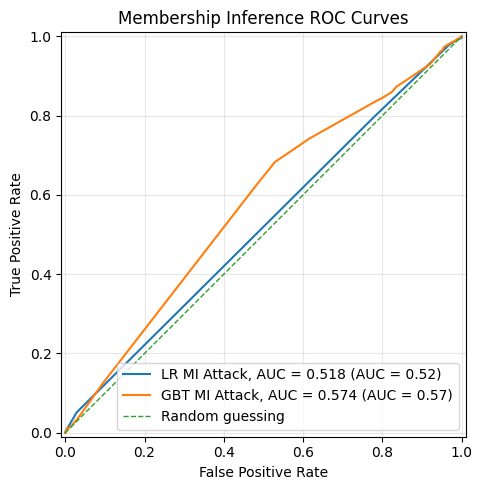

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, RocCurveDisplay

N_SHADOW = 10
RANDOM_STATE = 42


def train_shadow_mi_pipeline(X_train, y_train, model_type="LR", n_shadow=10, seed=42):
    shadow_train_confs = []
    shadow_test_confs = []

    sss = StratifiedShuffleSplit(
        n_splits=n_shadow,
        test_size=0.5,
        random_state=seed
    )

    print(f"\nTraining {n_shadow} {model_type} shadow models...")

    for i, (tr_idx, te_idx) in enumerate(sss.split(X_train, y_train), start=1):
        if model_type == "LR":
            shadow = LogisticRegression(max_iter=1000, random_state=seed)
        elif model_type == "GBT":
            shadow = GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=seed
            )
        else:
            raise ValueError("model_type must be 'LR' or 'GBT'.")

        shadow.fit(X_train[tr_idx], y_train[tr_idx])

        shadow_train_confs.append(
            shadow.predict_proba(X_train[tr_idx]).max(axis=1)
        )
        shadow_test_confs.append(
            shadow.predict_proba(X_train[te_idx]).max(axis=1)
        )

        if i % 5 == 0 or i == n_shadow:
            print(f"  Shadow model {i}/{n_shadow} trained")

    mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
    mi_y = np.concatenate(
        [np.ones(len(c)) for c in shadow_train_confs] +
        [np.zeros(len(c)) for c in shadow_test_confs]
    )

    meta_clf = DecisionTreeClassifier(max_depth=6, random_state=seed)
    meta_clf.fit(mi_X, mi_y)

    print(f"{model_type} meta-classifier samples: {len(mi_y):,}")

    return meta_clf


def attack_target_model(model_name, target_model, X_train, X_test, meta_clf):
    conf_train = target_model.predict_proba(X_train).max(axis=1).reshape(-1, 1)
    conf_test = target_model.predict_proba(X_test).max(axis=1).reshape(-1, 1)

    mi_scores_train = meta_clf.predict_proba(conf_train)[:, 1]
    mi_scores_test = meta_clf.predict_proba(conf_test)[:, 1]

    all_scores = np.concatenate([mi_scores_train, mi_scores_test])
    all_labels = np.concatenate([
        np.ones(len(mi_scores_train)),
        np.zeros(len(mi_scores_test))
    ])

    mi_auc = roc_auc_score(all_labels, all_scores)

    return {
        "Model": model_name,
        "MI AUC": mi_auc,
        "All Scores": all_scores,
        "All Labels": all_labels
    }


# 1) Create demo dataset
X, y = make_classification(
    n_samples=1500,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_clusters_per_class=2,
    class_sep=1.0,
    flip_y=0.02,
    random_state=RANDOM_STATE
)

Xs_tr, Xs_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# 2) Train target models
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
gbt = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

lr.fit(Xs_tr, y_tr)
gbt.fit(Xs_tr, y_tr)

lr_train_auc = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1])
lr_test_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
gbt_train_auc = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
gbt_test_auc = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])

# 3) Train shadow-model pipelines
mi_lr_shadow = train_shadow_mi_pipeline(
    X_train=Xs_tr,
    y_train=y_tr,
    model_type="LR",
    n_shadow=N_SHADOW,
    seed=RANDOM_STATE
)

mi_gbt_shadow = train_shadow_mi_pipeline(
    X_train=Xs_tr,
    y_train=y_tr,
    model_type="GBT",
    n_shadow=N_SHADOW,
    seed=RANDOM_STATE
)

# 4) Attack target models
mi_lr_result = attack_target_model(
    model_name="Logistic Regression",
    target_model=lr,
    X_train=Xs_tr,
    X_test=Xs_te,
    meta_clf=mi_lr_shadow
)

mi_gbt_result = attack_target_model(
    model_name="Gradient Boosted Tree",
    target_model=gbt,
    X_train=Xs_tr,
    X_test=Xs_te,
    meta_clf=mi_gbt_shadow
)

# 5) Summary table
mi_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosted Tree"],
    "Train AUC": [lr_train_auc, gbt_train_auc],
    "Test AUC": [lr_test_auc, gbt_test_auc],
    "Generalization Gap": [
        lr_train_auc - lr_test_auc,
        gbt_train_auc - gbt_test_auc
    ],
    "MI AUC": [
        mi_lr_result["MI AUC"],
        mi_gbt_result["MI AUC"]
    ]
})

print("\nMembership inference results:")
print(mi_results.round(3))

# 6) Plot ROC curves
plt.figure(figsize=(7, 5))

ax = plt.gca()

RocCurveDisplay.from_predictions(
    mi_lr_result["All Labels"],
    mi_lr_result["All Scores"],
    name=f"LR MI Attack, AUC = {mi_lr_result['MI AUC']:.3f}",
    ax=ax
)

RocCurveDisplay.from_predictions(
    mi_gbt_result["All Labels"],
    mi_gbt_result["All Scores"],
    name=f"GBT MI Attack, AUC = {mi_gbt_result['MI AUC']:.3f}",
    ax=ax
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random guessing")
plt.title("Membership Inference ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()